In [17]:
!wget https://www.dropbox.com/s/t4pzwpvrzneb190/training_set.zip
!wget https://www.dropbox.com/s/i37jfni3d29raoc/test_set.zip


--2024-10-01 16:58:00--  https://www.dropbox.com/s/t4pzwpvrzneb190/training_set.zip
Resolving www.dropbox.com (www.dropbox.com)... 162.125.81.18, 2620:100:6017:18::a27d:212
Connecting to www.dropbox.com (www.dropbox.com)|162.125.81.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://www.dropbox.com/scl/fi/1gen23zil5ni7ffhtiur1/training_set.zip?rlkey=royd23vjl40u1r59vzobpa873 [following]
--2024-10-01 16:58:01--  https://www.dropbox.com/scl/fi/1gen23zil5ni7ffhtiur1/training_set.zip?rlkey=royd23vjl40u1r59vzobpa873
Reusing existing connection to www.dropbox.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://uc75765a4c4d7de820d5c0f04582.dl.dropboxusercontent.com/cd/0/inline/Cbp-oJQaXhPbhHsYaGqb4Bnj0onLRgPVih3yj7ZwMAbxenMbML1alx91qRDyTEVh1Fg70DPSEUazShD5vq7rri7sJiHGfxTzkd98gHauv0NUuA9K0aznwERakynYHErBttkKYl3c9Y0zxe2ilgUKeXkK/file# [following]
--2024-10-01 16:58:02--  https://uc75765a4c4d7de820d5c0f04582.dl.dropboxusercontent.com

In [18]:
!unzip training_set.zip
!unzip test_set.zip

Streaming output truncated to the last 5000 lines.
  inflating: training_set/training_set/cats/cat.3704.jpg  
  inflating: training_set/training_set/cats/cat.3705.jpg  
  inflating: training_set/training_set/cats/cat.3706.jpg  
  inflating: training_set/training_set/cats/cat.3707.jpg  
  inflating: training_set/training_set/cats/cat.3708.jpg  
  inflating: training_set/training_set/cats/cat.3709.jpg  
  inflating: training_set/training_set/cats/cat.371.jpg  
  inflating: training_set/training_set/cats/cat.3710.jpg  
  inflating: training_set/training_set/cats/cat.3711.jpg  
  inflating: training_set/training_set/cats/cat.3712.jpg  
  inflating: training_set/training_set/cats/cat.3713.jpg  
  inflating: training_set/training_set/cats/cat.3714.jpg  
  inflating: training_set/training_set/cats/cat.3715.jpg  
  inflating: training_set/training_set/cats/cat.3716.jpg  
  inflating: training_set/training_set/cats/cat.3717.jpg  
  inflating: training_set/training_set/cats/cat.3718.jpg  
  infl

Populating the interactive namespace from numpy and matplotlib


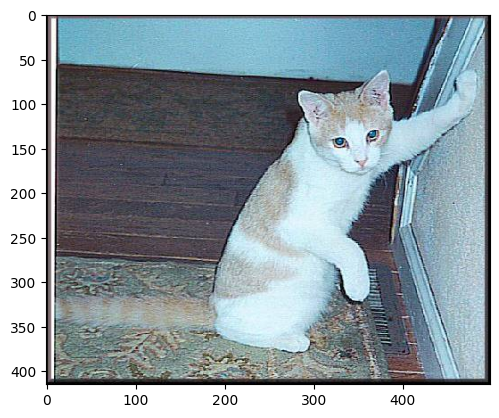

In [30]:
%pylab inline
import matplotlib.pyplot as plt
import matplotlib.image as npimg
img = npimg.imread('/content/test_set/test_set/cats/cat.4001.jpg')
imgplot = plt.imshow(img)
plt.show()

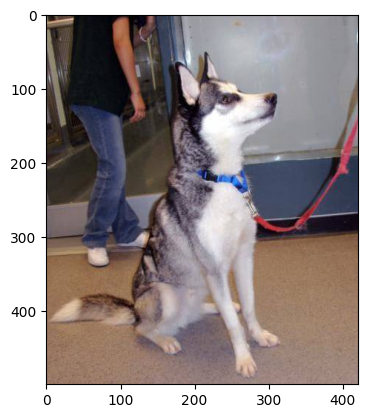

In [31]:
img = npimg.imread('/content/test_set/test_set/dogs/dog.4001.jpg')
imgplot = plt.imshow(img)
plt.show()

In [32]:
#Keras is an API that add more functionality and increase the visibility by giving a simple syntex
#Flatten change horizental to vertical

import tensorflow

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, Flatten, Dropout, MaxPooling2D, Activation
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

In [33]:
print (tensorflow.__version__)

2.17.0


In [34]:
img_width, img_height = 150,150
train_data_dir = r"/content/training_set/training_set"
validation_data_dir = r"/content/test_set/test_set"
nb_train_sample = 100  # Replace with actual number of training samples
nb_validation_samples = 100  # Replace with actual number of validation samples

epochs = 20
batch_size = 20

In [35]:
 import tensorflow.keras.backend as k
 if k.image_data_format() == 'channel_first':
  input_shape = (3, img_width, img_height)
 else:
  input_shape = (img_width, img_height,3)


In [36]:
#Using Binary classification we have to class cats and dogs that why

train_datagen = ImageDataGenerator (rescale=1. /255, shear_range=0.2,zoom_range=0.2,horizontal_flip=True)
test_datagen = ImageDataGenerator (rescale = 1. /255) #bringing RGB values from 0-255 to a range of 0-1
train_generator = train_datagen.flow_from_directory (train_data_dir, target_size = (img_width, img_height), batch_size = batch_size, class_mode = 'binary', classes = ['cats','dogs'])
validation_generator = test_datagen.flow_from_directory (validation_data_dir, target_size = (img_width,img_height), batch_size = batch_size, class_mode = 'binary')

Found 8005 images belonging to 2 classes.
Found 2023 images belonging to 2 classes.


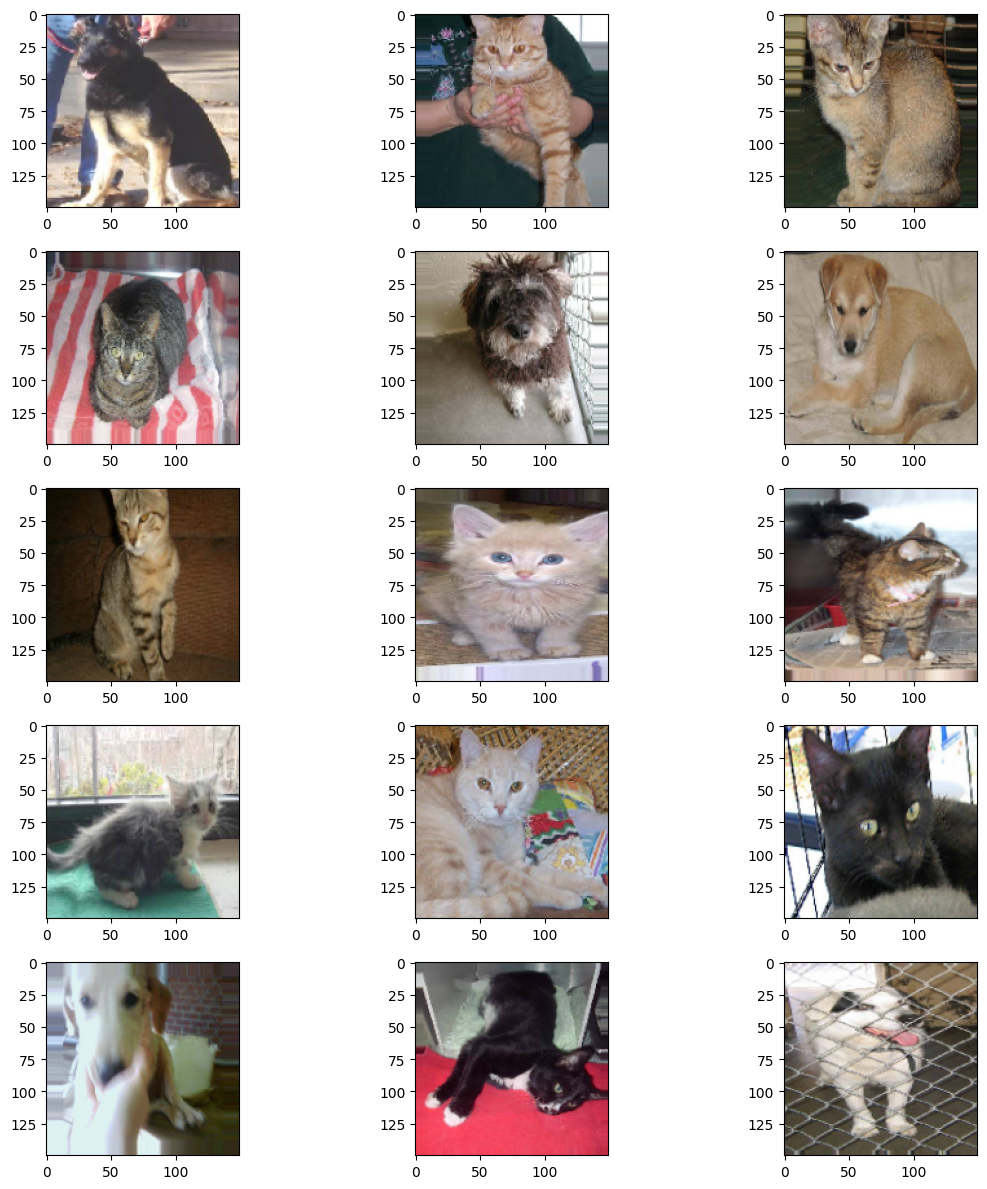

In [37]:
plt.figure(figsize=(12,12))
for i in range (0,15):
  plt.subplot(5,3,i+1)
  for X_batch, Y_batch in train_generator:
    image = X_batch[0]
    plt.imshow(image)
    break

plt.tight_layout()
plt.show()

In [38]:
model = Sequential()
model.add(Conv2D(64,(3,3), input_shape = input_shape)) #64 neurons using a 3x3 filter

model.add(Activation('relu'))
model .add(MaxPooling2D(pool_size = (2,2))) #pooling reduce the size of the data

model.add(Flatten()) #Conversion of multi-dimentional array to 1D array
model.add(Dense(64))

model.add(Activation('relu'))
model.add(Dense(1)) #output layer
model.add(Activation('sigmoid'))
model.summary()

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)                    │ (None, 148, 148, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_6 (Activation)            │ (None, 148, 148, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 74, 74, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 350464)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 64)                  │      22,429,760 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_7 (Activation)            │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │              65 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_8 (Activation)            │ (None, 1)                   │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 22,431,617 (85.57 MB)

 Trainable params: 22,431,617 (85.57 MB)

 Non-trainable params: 0 (0.00 B)

In [39]:
#We can also use another loss function but this loss function work very well so thats why i use it
#whenever you work on two classes this loss function work very well

model.compile(optimizer='rmsprop', loss = 'binary_crossentropy', metrics = ['accuracy'])
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)                    │ (None, 148, 148, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_6 (Activation)            │ (None, 148, 148, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 74, 74, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 350464)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 64)                  │      22,429,760 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_7 (Activation)            │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │              65 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_8 (Activation)            │ (None, 1)                   │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 22,431,617 (85.57 MB)

 Trainable params: 22,431,617 (85.57 MB)

 Non-trainable params: 0 (0.00 B)

In [41]:
training = model.fit(train_generator, steps_per_epoch = nb_train_sample,epochs = epochs, validation_data = validation_generator, validation_steps = nb_validation_samples)

"""training = model.fit(
    train_generator,
    steps_per_epoch=nb_train_sample // batch_size,  # Correct number of steps
    epochs=epochs,
    validation_data=validation_generator,
    validation_steps=nb_validation_samples // batch_size  # Correct validation steps
)"""


Epoch 1/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 123s 1s/step - accuracy: 0.5614 - loss: 0.7539 - val_accuracy: 0.5710 - val_loss: 0.6655
Epoch 2/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 99s 988ms/step - accuracy: 0.6347 - loss: 0.6588 - val_accuracy: 0.5652 - val_loss: 0.6967
Epoch 3/20


/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


100/100 ━━━━━━━━━━━━━━━━━━━━ 120s 1s/step - accuracy: 0.6671 - loss: 0.6323 - val_accuracy: 0.6950 - val_loss: 0.6011
Epoch 4/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 98s 982ms/step - accuracy: 0.6545 - loss: 0.6334 - val_accuracy: 0.4783 - val_loss: 0.8893
Epoch 5/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 24s 230ms/step - accuracy: 0.7000 - loss: 0.5070 - val_accuracy: 0.7000 - val_loss: 0.5781
Epoch 6/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 137s 984ms/step - accuracy: 0.6557 - loss: 0.6159 - val_accuracy: 1.0000 - val_loss: 0.3847
Epoch 7/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 121s 1s/step - accuracy: 0.6585 - loss: 0.6087 - val_accuracy: 0.6380 - val_loss: 0.6670
Epoch 8/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 120s 1s/step - accuracy: 0.6725 - loss: 0.6160 - val_accuracy: 0.6087 - val_loss: 0.6504
Epoch 9/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 120s 1s/step - accuracy: 0.6930 - loss: 0.6109 - val_accuracy: 0.6485 - val_loss: 0.6384
Epoch 10/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7000 - loss: 0.6503 - val_accuracy

'training = model.fit(\n    train_generator,\n    steps_per_epoch=nb_train_sample // batch_size,  # Correct number of steps\n    epochs=epochs,\n    validation_data=validation_generator,\n    validation_steps=nb_validation_samples // batch_size  # Correct validation steps\n)'

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


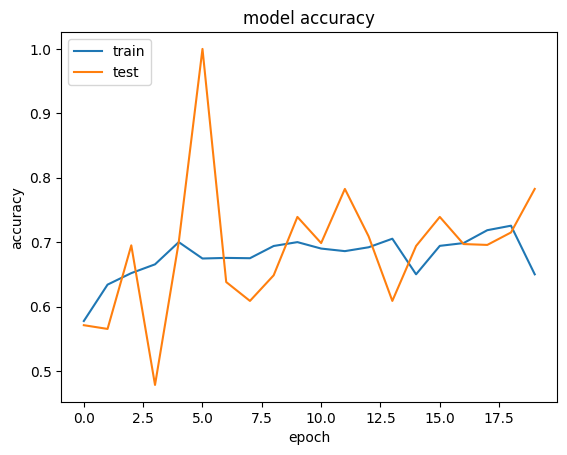

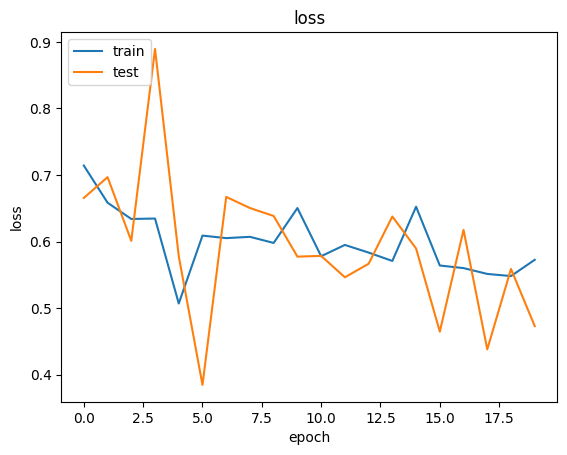

In [45]:
import matplotlib.pyplot as plt
%matplotlib inline

print (training.history.keys()) #Listing all training data
plt.plot(training.history['accuracy'])
plt.plot(training.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train','test'], loc ='upper left')
plt.show()

plt.plot(training.history['loss'])
plt.plot(training.history['val_loss'])
plt.title('loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train','test'], loc = 'upper left')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
[[0.]]
Prediction:  Cat


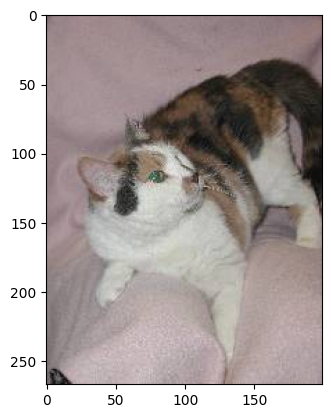

In [50]:
from tensorflow.keras.preprocessing import image
import numpy as np
img_pred = image.load_img("/content/test_set/test_set/cats/cat.4012.jpg", target_size = (150,150))

img_pred = image.img_to_array(img_pred)
img_pred = np.expand_dims(img_pred,axis=0)

rslt = model.predict(img_pred)
print(rslt)
if rslt[0][0] == 1:
  prediction = "Dog"
else:
  prediction = "Cat"

print("Prediction: ",prediction)

img = npimg.imread ("/content/test_set/test_set/cats/cat.4012.jpg")
imgplot = plt.imshow(img)
plt.show()
